# Abstract

Here we investigate the expected ability of a new remote-sensing stand-off infrared spectrometer, *Enfys*, for the ExoMars Rosalind Franklin Rover, to resolve diagnostic features of the reflectance spectra of key minerals previously identified on the surface of Mars.

# Introduction

## Background
ESA plans to land the ExoMars Rosalind Franklin Rover at the Oxia Planum region of Mars[^quantin-nataf2021] to characterise the geochemical and aqueous history of the environment and near subsurface (<2 m), and to search for signs of past or present life[^vago2017].

Previously the rover payload included a ROSCOSMOS (Russian) led instrument, the Infrared Spectrometer for ExoMars (ISEM)[^korablev2017]. Following the geopolitical fallout of the Russian invasion of Ukraine in 2021 the ISEM instrument was removed from the rover. A new UK-led instrument, *Enfys* (Welsh for 'rainbow'), has been approved at the ESA ministerial level to replace it.

The purpose of the spectrometer is to provide high spectral resolution observations of points of interest found in panoramic colour and multispectral image products, captured by the mast-mounted PanCam instrument[^coates2017] of the rover. The short-wave infrared range is sensitive to the IR-active H2O, OH, and CO3 molecules found in the carbonates and hydrated clays, sulphates and silicates that have been found previously on Mars, the presence of which can give insights to the geochemical and aqueous history of the environment. The high spectral resolution is required to resolve the subtle changes in the IR-active molecule band depths, positions and asymmetries that are induced by the presence of the various other elements and molecules in different mineral groups, species and phases.

## Enfys
The *Enfys* infrared spectrometer uses a scanning linear-variable-filter (LVF) optical design to observe incident narrowband intensity in the spectral range of 0.9 - 3.1 µm with a spectral resolving power of ~100, and with an expected signal-to-noise ratio of >2000 at 0.9 µm and >100 at 3.1 µm. The spectral range is covered by two photodiodes and two separate linear-variable filters; a 0.9 - 1.7 µm range filter is paired with an uncooled InGaAs photodiode, and the 1.6 - 3.1 µm range filter is paired with a cooled TE photodiode. The internal design of the system is shown in figure 1.

When an LVF of spectral range $\lambda_{lo} - \lambda_{hi}$ of active length $L$ is positioned such that the instrument optical path intersects the point $x \in [0, L]$, a transmission profile with centre-wavelength $\lambda_{cwl} \in [\lambda_{lo}, \lambda_{hi}]$ attenuates the transmitted spectral radiance. The `linear' part of the LVF name refers to the linear relationship between $\Delta x$ and $\Delta\lambda_{cwl}$. Typically, we expect the full-width-at-half-maximum to follow a linear relationship with $\lambda_{cwl} \forall \lambda_{cwl} \in [\lambda_{lo}, \lambda_{hi}]$, given by the spectral resolving power $\lambda/\Delta\lambda$. $\lambda/\Delta\lambda$ is a property of the filter and of the diameter of the optical beam path at the point of intersection (a larger beam path gives a lower spectral resolving power).

[^quantin-nataf2021]: Quantin-Nataf, C., Carter, J., Mandon, L., Thollot, P., Balme, M., Volat, M., Pan, L., Loizeau, D., Millot, C., Breton, S., Dehouck, E., Fawdon, P., Gupta, S., Davis, J., Grindrod, P. M., Pacifici, A., Bultel, B., Allemand, P., Ody, A., … Broyer, J. (2021). Oxia Planum: The Landing Site for the ExoMars “Rosalind Franklin” Rover Mission: Geological Context and Prelanding Interpretation. Astrobiology, 21(3). https://doi.org/10.1089/ast.2019.2191
[^vago2017]: Vago, J. L., Westall, F., Pasteur Instrument Teams, Landing S, Coates, A. J., Jaumann, R., Korablev, O., Ciarletti, V., Mitrofanov, I., Josset, J.-L., De Sanctis, M. C., Bibring, J.-P., Rull, F., Goesmann, F., Steininger, H., Goetz, W., Brinckerhoff, W., Szopa, C., Raulin, F., Westall, F., … the ExoMars Project Team. (2017). Habitability on Early Mars and the Search for Biosignatures with the ExoMars Rover. Astrobiology, 17(6–7), 471–510. https://doi.org/10.1089/ast.2016.1533
[^korablev2017]: Korablev, O. I., Dobrolensky, Y., Evdokimova, N., Fedorova, A. A., Kuzmin, R. O., Mantsevich, S. N., Cloutis, E. A., Carter, J., Poulet, F., Flahaut, J., Griffiths, A., Gunn, M., Schmitz, N., Martín-Torres, J., Zorzano, M.-P., Rodionov, D. S., Vago, J. L., Stepanov, A. V., Titov, A. Yu., … Ivanov, A. Yu. (2017). Infrared Spectrometer for ExoMars: A Mast-Mounted Instrument for the Rover. Astrobiology, 17(6–7), 542–564. https://doi.org/10.1089/ast.2016.1543
[^coates2017]: Coates, A. J., Jaumann, R., Griffiths, A. D., Leff, C. E., Schmitz, N., Josset, J.-L., Paar, G., Gunn, M., Hauber, E., Cousins, C. R., Cross, R. E., Grindrod, P., Bridges, J. c., Balme, M., Gupta, S., Crawford, I. A., Irwin, P., Stabbins, R., Tirsch, D., … the PanCam Team. (2017). The PanCam Instrument for the ExoMars Rover. Astrobiology, 17(6–7), 511–541. https://doi.org/10.1089/ast.2016.1548


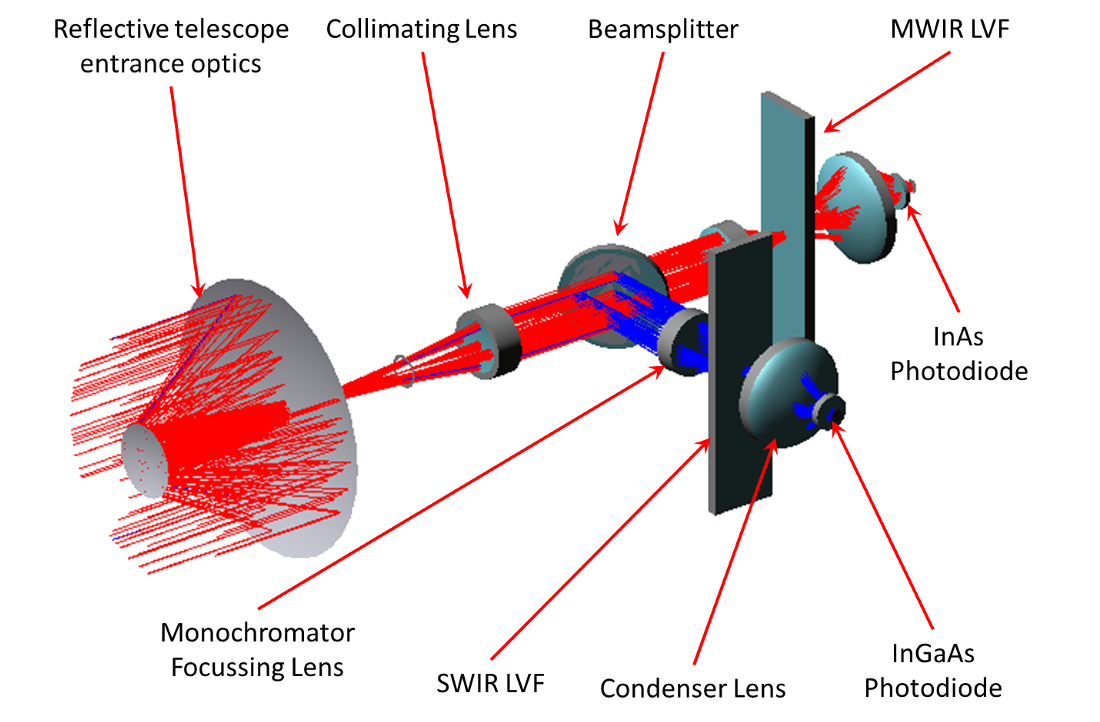

In [1]:
from IPython.display import display, Image, HTML
display(Image('enfys_diagram.png'))

**Figure 1** Schematic of the *Enfys* IR spectrometer optical path, showing the two Linear Variable Filters (SWIR LVF, MWIR LVF), and the two separate photodiodes.


## Problem
This optical design is functionally different to the Acousto-Optic Tunable Filter design of ISEM, so it is important that the design is demonstrated to fulfil the performance requirements of the instrument, and that expectations of performance can be set prior to laboratory tests of the completed instrument.

At time of writing, the spectrometer is in the development stage. This notebook describes how the Spectral Parameters Toolkit[^stabbins2024] can be used to convert the developing expectations of the spectral range and resolution and radiometric sensitivity of the instrument into predictions of its ability to discriminate mineral species and phases on the Mars surface at the rover landing site.

[^stabbins2024]: Stabbins, R., & Grindrod, P. (2024). The Spectral Parameters Toolkit (sptk): Release v0.1 (Version v0.1) [Computer software]. Zenodo. https://doi.org/10.5281/zenodo.10694286


# Method

To investigate the expected performance we use high-resolution laboratory measured spectra of a range of minerals expected at the Mars surface, and computationally simulate the sampling of the spectra with the expected spectral response of *Enfys*. We will perform repeat sampling with synthetically added noise to investigate the spectral and radiometric limits of the instrument.

We will produce a number of visualisations to investigate the predicted instrument performance, and demonstrate the limits of the instrument discriminatory ability.

## Spectral Resampling
We take a simple approach to resampling, as follows. 

We neglect reflectance calibration uncertainty, and any systematic uncertainty when merging the data from the two separate photodiodes, and assume that the linear-variable filter movement is perfectly calibrated such that a measurement at centre-wavelength $\lambda_{cwl}$ can be requested with arbitrary precision.

We assume an observation of $\lambda_{cwl}$ has a Cauchy transmission profile, and, prior to component characterisation, a spectral resolving power of $\lambda/\Delta\lambda=100$ is achieved for all $\lambda_{cwl}$, such that the Cauchy transmission profile for $\lambda_{cwl}$ has a full-width-at-half-maximum of $\Delta\lambda = \lambda_{cwl}/100$.

The Cauchy transmission profile $T(\lambda|\lambda_{cwl})$ is given by

$$
T(\lambda|\lambda_{cwl}) = \frac{\gamma^2}{(\lambda - \lambda_{cwl}^2) + \gamma^2}
$$

where $\gamma = \Delta\lambda/2 = (\lambda_{cwl}/100)/2$.

We assume that a high-resolution laboratory spectrum approximates the continuous function $R(\lambda)$, such that the calibrated reflectance at $\lambda_{cwl}$ has the expected value $R[\lambda_{cwl}]$ of:

$$
R[\lambda_{cwl}] = \frac{\int R(\lambda)T(\lambda|\lambda_{cwl}) d\lambda }{\int T(\lambda|\lambda_{cwl}) d\lambda}
$$

To simulate noise we add $\varepsilon$, an additive noise term that we draw from the Gaussian distribution with variance:

$$
\sigma^2 = \frac{\sqrt{R[\lambda_{cwl}]}}{\text{SNR}}
$$

under the assumption that maximum $\text{SNR}$ is only achieved for $R = 1$, and the noise is dominated by counting noise, such that $\sigma$ follows a Poissonian relationship with the signal $R$.

For each observation $R[\lambda_{cwl}]$ we draw 100 repeat samples, such that

$$
R_i[\lambda_{cwl}] = R[\lambda_{cwl}] + \varepsilon_i
$$

with 

$$
\varepsilon_i \sim \mathcal{N}\left(0, \frac{\sqrt{R[\lambda_{cwl}]}}{\text{SNR}}\right)
$$

This gives an indication of the expected noise of a calibrated *Enfys* acquired spectrum.

## Analysis

For now, we simply produce plots of the resampled spectra, and visually inspect the plots to consider the ability to resolve diagnostic spectral features against the noise. We will include more details of analysis as that is developed here.

## Notebook and Environment Setup

Here we include the required code blocks for setting up this notebook for this study.

In [2]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'svg' # note - requires Inkscape to be installed, and to be accessible from the terminal
# on macos, add inkscape to the path with `ln -s /Applications/Inkscape.app/Contents/MacOS/inkscape /usr/local/bin/inkscape`
%matplotlib inline

We will be using the Spectral Parameters Toolkit. First we import the required modules.

In [3]:
import sptk.config as cfg
from sptk.material_collection import MaterialCollection
from sptk.instrument import Instrument
from sptk.observation import Observation
from sptk.spectral_library_analyser import SpectralLibraryAnalyser as sla

We set our simulation resolution range to extend the range of Enfys, of 0.9 - 3.1 µm, such that the long tails of the Cauchy distribution of the linear-variable-filter profiles can be accommodated during sampling. We leave our spectral resolution at 1 nm for all $\lambda$.

In [4]:
cfg.update_sample_res('wvl_min', 850)
cfg.update_sample_res('wvl_max', 3300)

Finally we set the project name.

In [5]:
PROJECT_NAME = 'enfys_mica'

# Data

For this study we are using a spectral library of minerals identified through CRISM analysis ([the MICA files](http://crism.jhuapl.edu/data/mica/))[^viviano-beck2014]. Here we use the laboratory spectra that have been identified that best represent the type localities presented in the MICA files. These can be accessed [here](https://crismtypespectra.rsl.wustl.edu/), and are sourced from the RELAB and USGS public spectral libraries.

[^viviano-beck2014]: Viviano-Beck, C. E., Seelos, F. P., Murchie, S. L., Kahn, E. G., Seelos, K. D., Taylor, H. W., Taylor, K., Ehlmann, B. L., Wiseman, S. M., Mustard, J. F., & Morgan, M. F. (2014). Revised CRISM spectral parameters and summary products based on the currently detected mineral diversity on Mars. Journal of Geophysical Research: Planets, 119(6), 1403–1431. https://doi.org/10.1002/2014JE004627


We have grouped the spectral library into categories as follows, and included this categorisation in the sptk distribution, accessed from the ```sptk.material_sets``` module.

In [6]:
from sptk.material_sets import MICA_SET

We use the ```sptk.material_collection``` module to parse the spectral library:

In [7]:
matcol = MaterialCollection(
        MICA_SET,
        'MICA_new_dirtree', 
        PROJECT_NAME, 
        load_existing=False,
        balance_classes=False,
        random_bias_seed=None,
        allow_out_of_bounds=True,
        plot_profiles=False,
        export_df=True)

Building new enfys_mica MaterialCollection DF

---------------------------------
Category
└──species|subgroup|group|
   └──data_id status
---------------------------------
Iron Oxides & Primary Silicates
└──-clinopyroxene|pyroxenes|inosilicates|
   └──-NBPP22.csv loaded
└──-orthopyroxene|pyroxenes|inosilicates|
   └──-LAPP47B.csv loaded
└──-fayalite|olivines|nesosilicates|
   └──-LAPO05.csv loaded
└──-forsterite|olivines|nesosilicates|
   └──-LASC02.csv loaded
└──-hematite|hematites|oxides|
   └──-GDS27.csv loaded
└──-plagioclase|feldspars|tectosilicates|
   └──-NCLS04.csv loaded
---------------------------------
Sulfates
└──-alunite|hydrous_sulphates|sulphates|
   └──-F1CC08B.csv loaded
└──-bassanite|hydrous_sulphates|sulphates|
   └──-GDS145.csv loaded
└──-gypsum|hydrous_sulphates|sulphates|
   └──-LASF41A.csv loaded
└──-jarosite|hydrous_sulphates|sulphates|
   └──-LASF21A.csv loaded
└──-kieserite|hydrous_sulphates|sulphates|
   └──-F1CC15.csv loaded
└──-mg-sulphate|hydrous_sulphates

We can use the ```material_collection``` plotting routines to visualise the library.

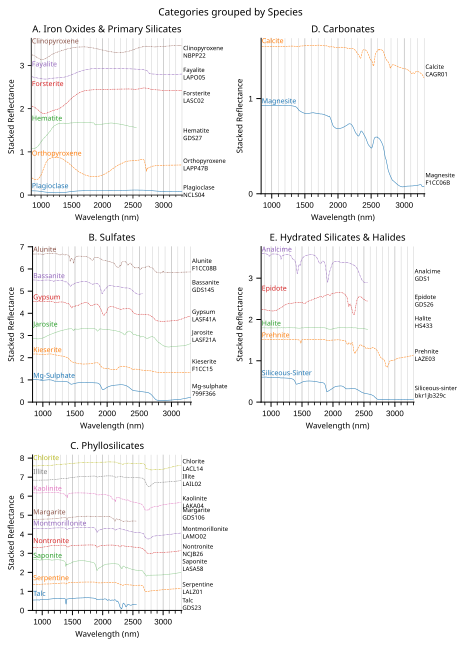

In [8]:
ax = matcol.plot_profiles(stacked=True, scope='categories', groupby='Species')

**Figure 2** High resolution MICA Files spectral library, arranged by category and grouped by mineral species.

We can see that not all of the entries cover the complete 0.9 - 3.1 µm range of *Enfys*, so in future work we should look to replace these MICA files laboratory type spectra with spectra that all span the entire range.

We can also produce a spectrogram visualisation, and alternative plotting method.

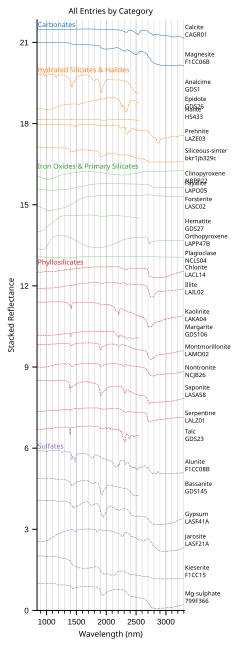

In [9]:
axes = matcol.plot_profiles(stacked=True, scope='all', groupby='Category')

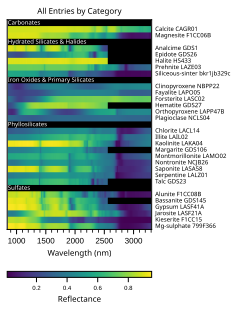

In [10]:
axes = matcol.plot_profiles(spectrogram=True, scope='all', groupby='Category')

# Results

## Simulating the Enfys Spectral Response

To simulate Enfys, rather than providing a file with the expected spectral response of each position of the Linear-Variable Filter (LVF, above), we specify the spectral range and resolution and sampling regime, and generate a set of central-wavelengths and bandwidths. We do this with the ```InstrumentBuilder``` class of the ```sptk.instrument``` module.

In [11]:
from sptk.instrument import InstrumentBuilder

The expected spectral resolution of Enfys is $\lambda/\Delta\lambda = 100$, and the range is 0.9 - 3.1 µm.

In [12]:
enfys_builder = InstrumentBuilder(
    instrument_name='enfys',
    instrument_type='lvf',
    sampling='nyquist',
    resolution = 100,
    spectral_range=[900, 3101],
    snr_range = [2000, 100])

Exporting instrument to ../data/instruments/enfys.csv...


In [13]:
from sptk.instrument import Instrument

Now we build the transmission profiles for each LVF position, according to the list of CWLs and FWHMs generated above. These are accessed by reading the ```.csv``` file produced by the ```InstrumentBuilder``` procedure.

When generating the profiles, we turn the CWL and FWHM into a profile by assuming a distribution function. For Enfys we use the Cauchy distribution, which beahves similarly to a Gaussian, but with wider 'wings'. It is parameterised by the full-width-at-half-maximum, as the distribution strictly has no finite variance. We have implemented a ```build_cauchy_filter``` method for the ```Instrument``` class.

In [14]:
enfys = Instrument(
            name = 'enfys', # filename of the instrument information, held in /software/data/instruments/            
            project_name = matcol.project_name, # the project directory name, hosting outputs in the /spectral_parameter_studies/ directory
            shape = 'cauchy',
            load_existing=False, # if True, load existing instrument data from the project directory
            plot_profiles=False, # if true, plot the transmission profiles during construction
            export_df=True) # if True, export the instrument transmission profiles to the project directory

Building Instrument...
Building new DataFrame for 'enfys'...
Exporting the Instrument to CSV and Pickle formats...


Plotting Instrument Transmission...
Plotting Signal-to-Noise Ratio...
Plotting Spectral Resolution...
Plotting FWHM...
Plots exported to ../projects/enfys_mica/instrument


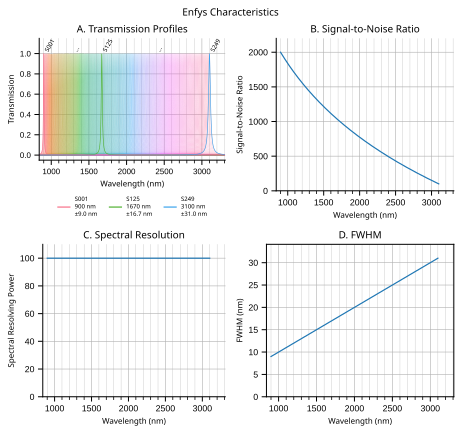

In [15]:
fig ,ax = enfys.plot_instrument_characteristics()

**Figure 3** Simulated spectral response and resolution of *Enfys*, based on preliminary expectations of the spectral and radiometric response.

The data shown in figure 3 approximates the expected performance of *Enfys*. Once the instrument is calibrated at the component and assembled levels, this data can be replaced with empirically aqcuired data.

## Sampling MICA with Enfys

We now make an ```Observation``` object by sampling the MICA files ```MaterialCollection``` with the Enfys ```Instrument```.

In [16]:
from sptk.observation import Observation

In [17]:
obs = Observation(
    material_collection=matcol,
    instrument = enfys,
    load_existing=False,
    plot_profiles=False,
    export_df=True)

Building new Observation DataFrame                                                  for 'enfys_mica'...
Sampling the Material Collection with the Instrument...
Sampling complete.
Exporting the Observation Pickle format...
Observation export complete.


We can plot the sampled spectra against the input high-spectra below:

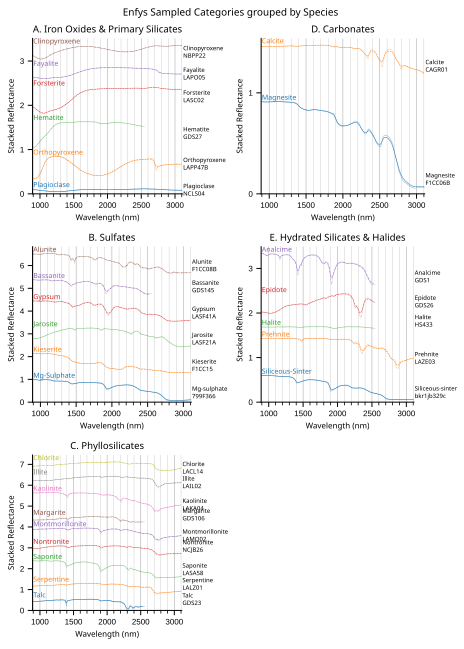

In [18]:
axes = obs.plot_profiles(scope='categories', groupby='Species', stacked=True, hires_under=True)

**Figure 4** The MICA files as sampled by *Enfys*, with the original high-resolution spectra plotted underneath each.

In [19]:
axes = obs.plot_profiles(spectrogram=True, scope='all', groupby='Category')

TypeError: Observation.plot_profiles() got an unexpected keyword argument 'spectrogram'

We can now see where there are deviations of the *Enfys* sampled spectra from the high-resolution source spectra. 

For example, illite, plotted below for clarity.

In [ ]:
axes = obs.plot_profiles(scope='illite', groupby='Sample ID', stacked=False, hires_under=True)

**Figure 5** Deviation of the *Enfys* sampled spectrum from the high-resolution input spectrum for Illite.

We note that there is an effect by which peaks and troughs in the spectra are reduced. This is due to the long tails of the Cauchy filter profiles. Despite the reduction of absolute band depth, the features of Illite (fig. 5) are still resolvable.

## Adding Synthetic Noise

As discussed in the method, we apply a simple additive Gaussian noise component, by redrawing $n=100$ additional measurements. We can plot the full range of the resultant samples, as shown again for the example of Illite below.

In [ ]:
noise_obs = obs.add_noise(100, seed=0)

In [ ]:
axes = obs.plot_profiles(scope='illite', groupby='Sample ID', stacked=False, hires_under=True, ci=False)

**Figure 6** Noisy resampled example spectrum for Illite, showing 100 repeat samples according to the spectral signal-to-noise ratio illustrated in figure 3.B.

We can also plot the mean observed line, with shading indicating the standard deviation of the noisy data, shown below in figure 7, where the 'ci' keywrod has been applied ('ci': confidence-interval).

In [ ]:
axes = obs.plot_profiles(scope='illite', groupby='Sample ID', stacked=False, hires_under=True, ci=True)

**Figure 7** Mean of Noisy resampled example spectrum for Illite, showing mean and standard deviation of 100 repeat samples according to the spectral signal-to-noise ratio illustrated in figure 3.B.

Here we find that the standard deviation is almost negligible at the scale of the figure.

Plotting out all of the groups, we again see that the noise, at this scale, is indeed negligible for most entries. Here we opt to plot the complete range of noisy samples, rather than averaging and showing the (very small) standard deviation.

In [ ]:
axes = obs.plot_profiles(scope='categories', groupby='Species', stacked=True, hires_under=True, ci=False)

**Figure 8** The MICA files as sampled by *Enfys*, with repeat samples drawn according to the expected spectral Signal-to-Noise Ratio, with the original high-resolution spectra plotted underneath each.

The key conclusion to draw from the above figure is that expected noise for *Enfys* does not significantly intrude on the diagnostic features of these type specimen of minerals identified on the Mars surface.

We can illustrate this in greater deal by plotting each entry on a separate figure, with the y-axis clipped to the spectral range of entry. Note that for sample with a small spectral range (i.e. samples that are spectrally flat), this stretching will appear to amplify noise, so the y-axis range must be considered when assessing the noise.

In [ ]:
axes = obs.plot_profiles(scope='samples', groupby='Species', stacked=False, hires_under=True, ci=False)

## Continuum Removal

We can apply continuum removal, even to the noisy data.

In [ ]:
from sptk.spectral_library_analyser import SpectralLibraryAnalyser as sla

cr_tool = sla(obs)
cr_obs = cr_tool.remove_continuum()

In [ ]:
cr_obs.main_df

In [ ]:
axes = cr_obs.plot_profiles(scope='categories', groupby='Species', stacked=True, hires_under=False, ci=False)

## Spectrogram Visualisation

In [ ]:
axes = cr_tool.visualise_spectrogram()

# Discussion

Notes on what we found above, perhaps with some more analysis.

# Conclusions

Concluding remarks and summary of findings.

# References